# Mini Demo: Inference Layer + Policy Comparison

This notebook illustrates two pieces on a toy setup:

1. **Inference layer** for one asked item and one observed response
   - prior predictive category probabilities
   - one-step coefficients `(m, v, p_r)`
   - projected variance before/after undamped and damped updates

2. **Policy layer** on a mini item bank
   - unweighted surrogate: `log(1 + a^T Sigma a)`
   - weighted surrogate: `log(1 + p_stay(i,k) * a^T Sigma a)`
   - selected item under each policy


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Robustly locate project root whether notebook cwd is repo root or notebooks/
if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.belief import BeliefState
from src.item_bank import Item
from src.grm import category_probabilities
from src.updates import (
    projected_mean_variance,
    one_step_posterior_coefficients,
    update_belief,
    damped_update_belief,
)
from src.policies import (
    make_linear_sensitivity_stay_prob,
    score_bank,
    select_next_item,
)

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\49160\Adaptive-Onboarding


In [2]:
# --- Mini dummy setup ---
belief0 = BeliefState(
    mu=np.array([0.4, -0.3]),
    Sigma=np.array([[1.2, 0.25], [0.25, 0.9]]),
)

item_focus = Item(
    item_id="q_focus",
    a=np.array([1.0, -0.6]),
    thresholds=np.array([-0.7, 0.3]),
    behavioral_sensitivity=0.4,
)

observed_response = 1  # middle category for this 3-category item

item_bank = [
    item_focus,
    Item("q_sleep",   np.array([0.9,  0.1]), np.array([-0.5, 0.4]), behavioral_sensitivity=0.1),
    Item("q_support", np.array([0.2, -1.1]), np.array([-0.3, 0.6]), behavioral_sensitivity=0.2),
    Item("q_risk",    np.array([1.1, -0.2]), np.array([-1.0, 0.0]), behavioral_sensitivity=0.9),
]

# Stay probability model from the chapter's stylized form
stay_prob_fn = make_linear_sensitivity_stay_prob(
    gamma0=0.65,
    gamma_step=0.10,
)


## 1) Inference layer on one item + one observed response

In [3]:
prior_probs = category_probabilities(belief0, item_focus)
m, v, p_r = one_step_posterior_coefficients(belief0, item_focus, observed_response)

belief_undamped = update_belief(belief0, item_focus, observed_response)
belief_damped = damped_update_belief(belief0, item_focus, observed_response)

_, var_prior = projected_mean_variance(belief0, item_focus)
_, var_undamped = projected_mean_variance(belief_undamped, item_focus)
_, var_damped = projected_mean_variance(belief_damped, item_focus)

print("Prior category probabilities:")
for r, p in enumerate(prior_probs):
    marker = " <- observed" if r == observed_response else ""
    print(f"  r={r}: {p:.4f}{marker}")

print(f"\nm = {m:+.4f}")
print(f"v = {v:.4f}")
print(f"p_r = {p_r:.4f}")

print("\nProjected variance a^T Sigma a:")
print(f"  before update         : {var_prior:.4f}")
print(f"  after undamped update : {var_undamped:.4f}")
print(f"  after damped update   : {var_damped:.4f}")


Prior category probabilities:
  r=0: 0.2147
  r=1: 0.2167 <- observed
  r=2: 0.5686

m = -0.3186
v = 0.5481
p_r = 0.2167

Projected variance a^T Sigma a:
  before update         : 1.2240
  after undamped update : 0.6709
  after damped update   : 1.0385


<>:17: SyntaxWarning: invalid escape sequence '\S'
<>:17: SyntaxWarning: invalid escape sequence '\S'
C:\Users\49160\AppData\Local\Temp\ipykernel_27332\1426409442.py:17: SyntaxWarning: invalid escape sequence '\S'
  axes[1].set_title("Projected variance $a^T\Sigma a$")


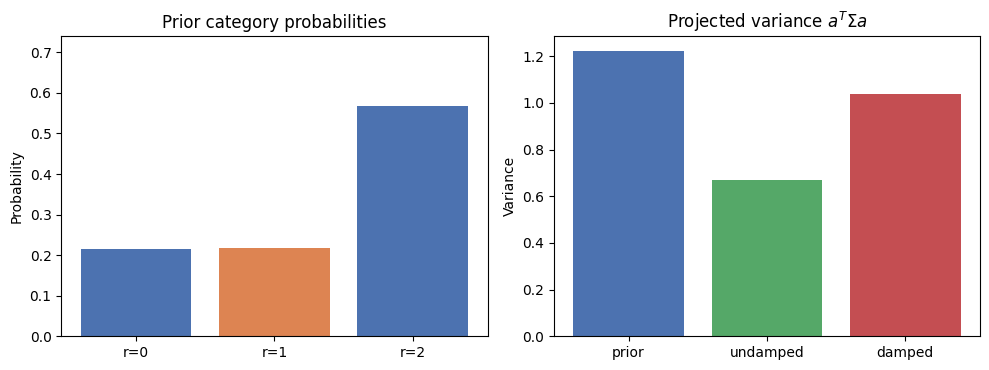

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# Prior category probabilities
colors = ["#4C72B0"] * len(prior_probs)
colors[observed_response] = "#DD8452"
axes[0].bar(range(len(prior_probs)), prior_probs, color=colors)
axes[0].set_xticks(range(len(prior_probs)))
axes[0].set_xticklabels([f"r={r}" for r in range(len(prior_probs))])
axes[0].set_title("Prior category probabilities")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, max(prior_probs) * 1.3)

# Projected variance before/after updates
var_labels = ["prior", "undamped", "damped"]
var_values = [var_prior, var_undamped, var_damped]
axes[1].bar(var_labels, var_values, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_title("Projected variance $a^T\Sigma a$")
axes[1].set_ylabel("Variance")

plt.tight_layout()
plt.show()


## 2) Unweighted vs weighted policy on the same belief state

In [5]:
step = 0

scored_unweighted = score_bank(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    weighted=False,
    stay_prob_fn=stay_prob_fn,
)

scored_weighted = score_bank(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    weighted=True,
    stay_prob_fn=stay_prob_fn,
)

print("Unweighted ranking (log(1 + a^T Sigma a)):")
for rank, row in enumerate(scored_unweighted, start=1):
    print(
        f"  {rank}. {row.item.item_id:10s} score={row.score:.4f} "
        f"var={row.projected_variance:.4f} p_stay={row.stay_prob:.3f}"
    )

print("\nWeighted ranking (log(1 + p_stay * a^T Sigma a)):")
for rank, row in enumerate(scored_weighted, start=1):
    print(
        f"  {rank}. {row.item.item_id:10s} score={row.score:.4f} "
        f"var={row.projected_variance:.4f} p_stay={row.stay_prob:.3f}"
    )

sel_unweighted = select_next_item(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    strategy="surrogate_unweighted",
    stay_prob_fn=stay_prob_fn,
)
sel_weighted = select_next_item(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    strategy="surrogate_weighted",
    stay_prob_fn=stay_prob_fn,
)

print("\nSelected next item:")
print("  unweighted:", sel_unweighted.item_id)
print("  weighted  :", sel_weighted.item_id)


Unweighted ranking (log(1 + a^T Sigma a)):
  1. q_risk     score=0.8663 var=1.3780 p_stay=1.000
  2. q_focus    score=0.7993 var=1.2240 p_stay=1.000
  3. q_support  score=0.7066 var=1.0270 p_stay=1.000
  4. q_sleep    score=0.7061 var=1.0260 p_stay=1.000

Weighted ranking (log(1 + p_stay * a^T Sigma a)):
  1. q_sleep    score=0.6726 var=1.0260 p_stay=0.935
  2. q_focus    score=0.6449 var=1.2240 p_stay=0.740
  3. q_support  score=0.6384 var=1.0270 p_stay=0.870
  4. q_risk     score=0.4523 var=1.3780 p_stay=0.415

Selected next item:
  unweighted: q_risk
  weighted  : q_sleep


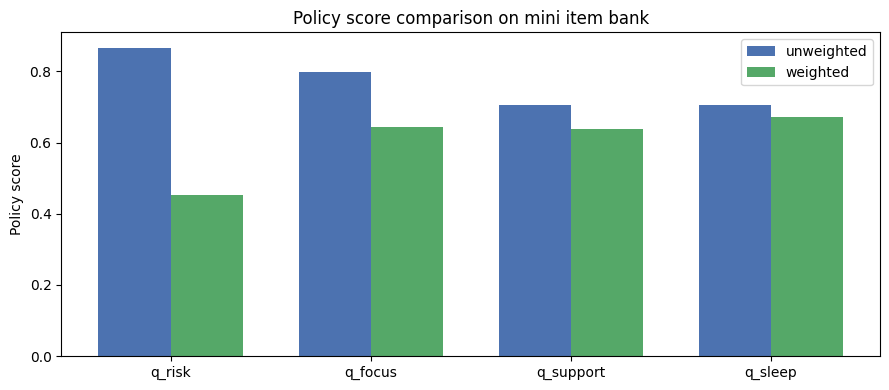

In [6]:
# Side-by-side score visualization
item_ids = [row.item.item_id for row in scored_unweighted]
unweighted_scores = [row.score for row in scored_unweighted]
weighted_lookup = {row.item.item_id: row.score for row in scored_weighted}
weighted_scores = [weighted_lookup[iid] for iid in item_ids]

x = np.arange(len(item_ids))
w = 0.36

plt.figure(figsize=(9, 4))
plt.bar(x - w / 2, unweighted_scores, width=w, label="unweighted", color="#4C72B0")
plt.bar(x + w / 2, weighted_scores, width=w, label="weighted", color="#55A868")
plt.xticks(x, item_ids)
plt.ylabel("Policy score")
plt.title("Policy score comparison on mini item bank")
plt.legend()
plt.tight_layout()
plt.show()


## 3) Optional: one tiny 3-step trajectory (deterministic responses)

To keep this demo reproducible, we pick the most likely response category at each step.


In [7]:
def argmax_response(belief: BeliefState, item: Item) -> int:
    p = category_probabilities(belief, item)
    return int(np.argmax(p))


def run_three_steps(strategy: str):
    belief = belief0
    asked = []
    trace = []
    for k in range(3):
        item = select_next_item(
            belief=belief,
            item_bank=item_bank,
            step=k,
            strategy=strategy,
            already_asked=asked,
            stay_prob_fn=stay_prob_fn,
        )
        r = argmax_response(belief, item)
        old_var = float(item.a @ belief.Sigma @ item.a)
        belief = update_belief(belief, item, r)
        new_var = float(item.a @ belief.Sigma @ item.a)
        asked.append(item.item_id)
        trace.append((k, item.item_id, r, old_var, new_var))
    return trace


for strategy in ["surrogate_unweighted", "surrogate_weighted"]:
    print(f"\nStrategy: {strategy}")
    for k, item_id, r, old_var, new_var in run_three_steps(strategy):
        print(f"  step={k} item={item_id:10s} response={r} queried-var: {old_var:.4f} -> {new_var:.4f}")



Strategy: surrogate_unweighted
  step=0 item=q_risk     response=2 queried-var: 1.3780 -> 1.0466
  step=1 item=q_support  response=2 queried-var: 1.0231 -> 0.7141
  step=2 item=q_focus    response=2 queried-var: 0.8942 -> 0.7299

Strategy: surrogate_weighted
  step=0 item=q_sleep    response=2 queried-var: 1.0260 -> 0.7057
  step=1 item=q_support  response=2 queried-var: 1.0222 -> 0.7057
  step=2 item=q_focus    response=2 queried-var: 0.8723 -> 0.7247
